# Toy Example for RUV-VAE / scVI

## Design

- **Conditions**: A, B, C, D
- **Batches**: 1, 2, 3, 4
- **Features** per cell: 2 (`gene1`, `gene2`)

Cell counts per condition × batch:

|         | batch_1 | batch_2 | batch_3 | batch_4 |
|---------|:-------:|:-------:|:-------:|:-------:|
| **A**   |   30    |   30    |   30    |    -    |
| **B**   |   30    |   30    |   30    |    -    |
| **C**   |    -    |    -    |   30    |    -    |
| **D**   |    -    |    -    |   30    |    -    |

So:
- **A** and **B** span batches 1, 2, 3 → they can act as *anchors* for batch-effect estimation.
- **C** and **D** live only in batch 3 → they are *batch-confounded* with respect to any other condition in batch 3 (i.e. you cannot separate their condition effect from the batch-3 shift using only batch-3 cells, you need the A/B anchors across batches).

## Generative model

`y = condition_effect + batch_effect + noise`

- condition means (2D): A=(0,0), B=(3,0), C=(0,3), D=(3,3)
- additive batch shifts (2D): b1=(0,0), b2=(1, 0.5), b3=(0.5, 1)
- noise: `N(0, 0.3²)` per feature

The "true" condition effect on each gene is recoverable once the batch effect has been estimated (e.g. by RUV or scVI with batch as a covariate).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata

rng = np.random.default_rng(42)

In [12]:
# ----- design -----
conditions = ['A', 'B', 'C', 'D']
batches    = [1, 2, 3, 4]

# cells per (condition, batch)
n_cells_map = {
    ('A', 1): 30, ('A', 2): 30, ('A', 3): 30,
    ('B', 1): 30, ('B', 2): 30, ('B', 3): 30,
    ('C', 3): 30,
    ('D', 3): 30,
}

# true condition means in 2D
cond_mean = {
    'A': np.array([0.0, 0.0]),
    'B': np.array([3.0, 0.0]),
    'C': np.array([0.0, 3.0]),
    'D': np.array([3.0, 3.0]),
}

# additive batch shifts in 2D
batch_shift = {
    1: np.array([0.0, 0.0]),
    2: np.array([1.5, 1.5]),
    3: np.array([0.5, 1.5]),
    4: np.array([0.0, 0.0]),   # unused
}

noise_std = 0.3

# ----- sample -----
records = []
for (cond, batch), n in n_cells_map.items():
    mean = cond_mean[cond] + batch_shift[batch]
    X = rng.normal(loc=mean, scale=noise_std, size=(n, 2))
    for i in range(n):
        records.append({
            'cell_id':   f'{cond}_b{batch}_{i:03d}',
            'condition': cond,
            'batch':     f'batch_{batch}',
            'batch_num': batch,
            'gene1':     X[i, 0],
            'gene2':     X[i, 1],
        })

df = pd.DataFrame(records)
print(f"Total cells: {len(df)}")
df.head()

Total cells: 240


,cell_id,condition,batch,batch_num,gene1,gene2
0,A_b1_000,A,batch_1,1,0.091415,-0.311995
1,A_b1_001,A,batch_1,1,0.225135,0.282169
2,A_b1_002,A,batch_1,1,-0.585311,-0.390654
3,A_b1_003,A,batch_1,1,0.038352,-0.094873
4,A_b1_004,A,batch_1,1,-0.005040,-0.255913


In [13]:
summary = (
    df.groupby(['condition', 'batch'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=conditions,
               columns=[f'batch_{b}' for b in batches],
               fill_value=0)
)
summary

batch,batch_1,batch_2,batch_3,batch_4
condition,,,,
A,30,30,30,0
B,30,30,30,0
C,0,0,30,0
D,0,0,30,0


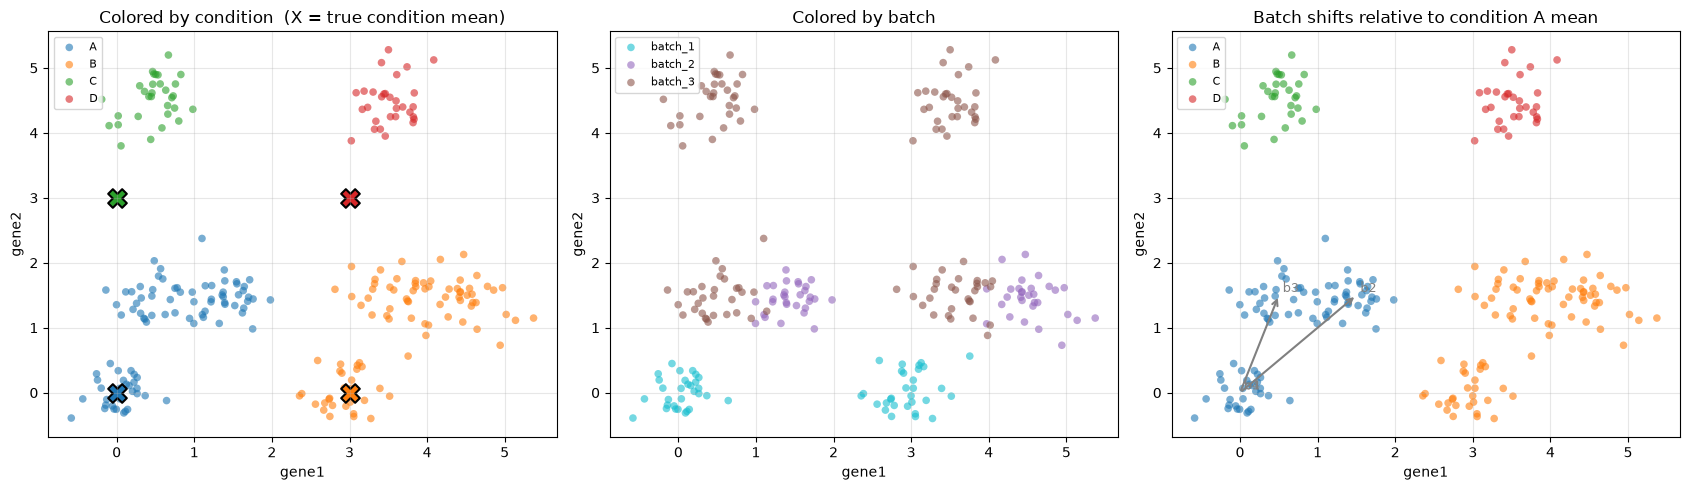

In [14]:
cond_colors  = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728'}
batch_colors = {1: '#17becf', 2: '#9467bd', 3: '#8c564b', 4: '#e377c2'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- panel 1: colored by condition, with true condition means ---
for cond in conditions:
    sub = df[df['condition'] == cond]
    axes[0].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
for cond, m in cond_mean.items():
    axes[0].scatter(m[0], m[1], c=cond_colors[cond], marker='X', s=180,
                    edgecolors='black', linewidths=1.5)
axes[0].set_title('Colored by condition  (X = true condition mean)')
axes[0].set_xlabel('gene1'); axes[0].set_ylabel('gene2')
axes[0].legend(loc='upper left', fontsize=8); axes[0].grid(alpha=0.3)

# --- panel 2: colored by batch ---
for b in batches:
    sub = df[df['batch_num'] == b]
    if len(sub) == 0:
        continue
    axes[1].scatter(sub['gene1'], sub['gene2'], c=batch_colors[b],
                    label=f'batch_{b}', alpha=0.6, s=30, edgecolors='none')
axes[1].set_title('Colored by batch')
axes[1].set_xlabel('gene1'); axes[1].set_ylabel('gene2')
axes[1].legend(loc='upper left', fontsize=8); axes[1].grid(alpha=0.3)

# --- panel 3: how batch shifts move the A cluster ---
for cond in conditions:
    sub = df[df['condition'] == cond]
    axes[2].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
# draw batch-shift arrows starting from condition A mean
for b, s in batch_shift.items():
    axes[2].annotate('', xy=cond_mean['A'] + s, xytext=cond_mean['A'],
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    axes[2].text(*(cond_mean['A'] + s + np.array([0.05, 0.05])),
                 f'b{b}', fontsize=9, color='gray')
axes[2].set_title('Batch shifts relative to condition A mean')
axes[2].set_xlabel('gene1'); axes[2].set_ylabel('gene2')
axes[2].legend(loc='upper left', fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
adata = anndata.AnnData(
    X=df[['gene1', 'gene2']].values.astype(np.float32),
    obs=df[['cell_id', 'condition', 'batch', 'batch_num']].set_index('cell_id'),
    var=pd.DataFrame(index=['gene1', 'gene2']),
)

# store raw counts for scVI (here counts == normalized because toy is small)
adata.layers['counts'] = adata.X.copy()

# ground-truth batch effect per cell, useful for sanity checks
adata.obsm['X_true_cond']    = np.array([cond_mean[c] for c in adata.obs['condition']])
adata.obsm['X_true_batch']   = np.array([batch_shift[b] for b in adata.obs['batch_num']])
adata.obsm['X_true_latent']  = adata.obsm['X_true_cond'] + adata.obsm['X_true_batch']

print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 240 × 2
    obs: 'condition', 'batch', 'batch_num'
    obsm: 'X_true_cond', 'X_true_batch', 'X_true_latent'
    layers: None (.X), 'counts'


,condition,batch,batch_num
cell_id,,,
A_b1_000,A,batch_1,1
A_b1_001,A,batch_1,1
A_b1_002,A,batch_1,1
A_b1_003,A,batch_1,1
A_b1_004,A,batch_1,1


## What to do with this toy

This `adata` is ready to feed into scVI / scvi-tools / RUV-VAE as a 2-feature dataset:

```python
import scvi
scvi.model.SCVI.setup_anndata(adata, batch_key='batch', layer='counts')
model = scvi.model.SCVI(adata)
model.train()
```

A few useful sanity checks you can run after training:

- `adata.obsm['X_scVI']` should look like `X_true_latent` after subtracting the per-batch shift.
- Differential expression between `A` vs `C` (both in batch 3) is confounded by the batch-3 shift unless you condition on `batch` (or use RUV-style negative controls). Comparing `A` (b1) vs `C` (b3) is *not* confounded.
- Because A and B each span batches 1/2/3, they can be used to *estimate* the batch-3 shift, which can then be removed from C and D.

## Algorithm: minimum-movement batch swap with condition repulsion

We want to move each cell's 2D coordinates `y` by a small displacement `Δy` that simultaneously satisfies three constraints:

1. **Minimum movement** — `‖Δy‖` is as small as possible (per cell).
2. **Cross-batch swap** — after the move, `y + Δy` is *closer to a different batch centroid than to its own*.
3. **Condition separation** — after the move, the centroids of different conditions are as far apart as possible.

### Core idea

We decompose the displacement into two pieces:

```
Δy_i = Δ_swap_i   +   w · Δ_repel_i
         ↑                  ↑
   minimum move that    repulsion from the
   crosses the batch    centroids of OTHER
   Voronoi boundary     conditions (c ≠ c_i)
```

- `Δ_swap_i` is **the shortest vector from `y_i` to the perpendicular bisector between its own batch centroid `μ_{b_i}` and its closest other-batch centroid `μ_{b*}`**, pushed just past the boundary.
- `Δ_repel_i = Σ_{c ≠ c_i} (y_i − ν_c) / ‖y_i − ν_c‖` is a unit-vector sum pushing the cell away from other condition centroids `ν_c`.

Both terms are small, so `‖Δy_i‖` stays close to its minimum possible value (constraint 1). The swap direction puts the cell into a *different* batch region (constraint 2). The repulsion term moves different conditions apart (constraint 3).

We iterate recomputing batch and condition centroids after every round so the targets track the moving cells.

In [25]:
def batch_centroids_of(Y, batches, batch_list):
    """Mean position of every cell currently in each batch."""
    out = {}
    for b in batch_list:
        mask = (batches == b)
        if mask.any():
            out[b] = Y[mask].mean(axis=0)
    return out

def condition_centroids_of(Y, conditions, cond_list):
    out = {}
    for c in cond_list:
        mask = (conditions == c)
        if mask.any():
            out[c] = Y[mask].mean(axis=0)
    return out


def closest_other_batch(y_i, b_i, mu):
    """Closest batch centroid to y_i among batches b ≠ b_i."""
    best_b, best_d = None, np.inf
    for b, m in mu.items():
        if b == b_i:
            continue
        d = float(np.linalg.norm(y_i - m))
        if d < best_d:
            best_b, best_d = b, d
    return best_b, best_d


def swap_displacement(y_i, mu_self, mu_other, eps=1e-3):
    """
    Minimum displacement that takes y_i from its own Voronoi cell into
    mu_other's Voronoi cell, then pushed a tiny `eps` past the boundary.
    Returns the displacement vector (may be ~zero if already on the other side).
    """
    delta = mu_other - mu_self
    denom = float(np.dot(delta, delta))
    if denom < 1e-12:
        return np.zeros_like(y_i)
    proj = float(np.dot(y_i - mu_self, delta)) / denom
    if proj >= 0.5:
        return np.zeros_like(y_i)            # already in mu_other's cell
    target = mu_self + (0.5 + eps) * delta   # just past the perpendicular bisector
    return target - y_i


def condition_repulsion(y_i, c_i, nu, cond_list):
    """Sum of unit vectors pointing AWAY from every other-condition centroid."""
    out = np.zeros_like(y_i)
    for c in cond_list:
        if c == c_i:
            continue
        diff = y_i - nu[c]
        n = np.linalg.norm(diff)
        if n > 1e-12:
            out += diff / n
    return out


# ----- run the algorithm -----
batches_arr   = df['batch_num'].to_numpy()
conditions_arr = df['condition'].to_numpy()
Y0 = df[['gene1', 'gene2']].to_numpy().astype(float)

# Two phases:
#  Phase A — minimal-movement cross-batch swap (one shot; satisfies 1 + 2).
#  Phase B — a few refinement rounds that add a small condition-repulsion
#            step (still small, but enough to spread the conditions out, 3).

# ---- Phase A: pure swap ----
mu = batch_centroids_of(Y0, batches_arr, batches)
nu = condition_centroids_of(Y0, conditions_arr, conditions)

Y = Y0.copy()
disp_A = np.zeros(len(Y0))
for i in range(len(Y0)):
    y_i    = Y0[i]
    b_i    = batches_arr[i]
    mu_self = mu[b_i]
    b_star, _ = closest_other_batch(y_i, b_i, mu)
    d_swap = swap_displacement(y_i, mu_self, mu[b_star])
    Y[i] = y_i + d_swap
    disp_A[i] = np.linalg.norm(d_swap)

print(f"[Phase A] mean swap displacement per cell: {disp_A.mean():.3f}")

# ---- Phase B: small condition-repulsion refinement ----
n_iter   = 2        # few extra rounds
w_repel  = 0.01     # fraction of the original swap magnitude, applied each round

history = {'iteration': [], 'mean_disp': [], 'cond_sep': []}
base_swap_mag = float(disp_A.mean()) if disp_A.mean() > 0 else 1.0

for it in range(n_iter):
    mu = batch_centroids_of(Y, batches_arr, batches)
    nu = condition_centroids_of(Y, conditions_arr, conditions)

    new_Y    = Y.copy()
    disp_step = np.zeros(len(Y))

    for i in range(len(Y)):
        y_i = Y[i]
        c_i = conditions_arr[i]
        d_rep = condition_repulsion(y_i, c_i, nu, conditions)
        # step size: a fixed fraction of the original swap distance,
        # so the total movement is still of the same order as the
        # minimum-movement swap.
        step = w_repel * base_swap_mag
        nrm  = np.linalg.norm(d_rep)
        if nrm > 1e-12:
            new_Y[i] = y_i + step * d_rep / nrm
            disp_step[i] = step
        else:
            disp_step[i] = 0.0

    history['iteration'].append(it + 1)
    history['mean_disp'].append(float(disp_step.mean()))
    nu_after = condition_centroids_of(new_Y, conditions_arr, conditions)
    pairs = [(c1, c2) for i, c1 in enumerate(conditions)
             for c2 in conditions[i+1:]]
    history['cond_sep'].append(float(np.mean(
        [np.linalg.norm(nu_after[a] - nu_after[b]) for a, b in pairs]
    )))

    Y = new_Y

df_moved = df.copy()
df_moved['gene1'] = Y[:, 0]
df_moved['gene2'] = Y[:, 1]
total_disp = np.linalg.norm(Y - Y0, axis=1)
print(f"[Phase B] mean repulsion step per cell per round: "
      f"{history['mean_disp'][-1]:.3f}")
print(f"Total mean displacement per cell (swap + repulsion): "
      f"{total_disp.mean():.3f}")
print(f"Mean inter-condition centroid distance (final): "
      f"{history['cond_sep'][-1]:.3f}")
history_df = pd.DataFrame(history)
history_df

[Phase A] mean swap displacement per cell: 1.380
[Phase B] mean repulsion step per cell per round: 0.014
Total mean displacement per cell (swap + repulsion): 1.384
Mean inter-condition centroid distance (final): 1.067


,iteration,mean_disp,cond_sep
0,1,0.013804,1.051935
1,2,0.013804,1.067324


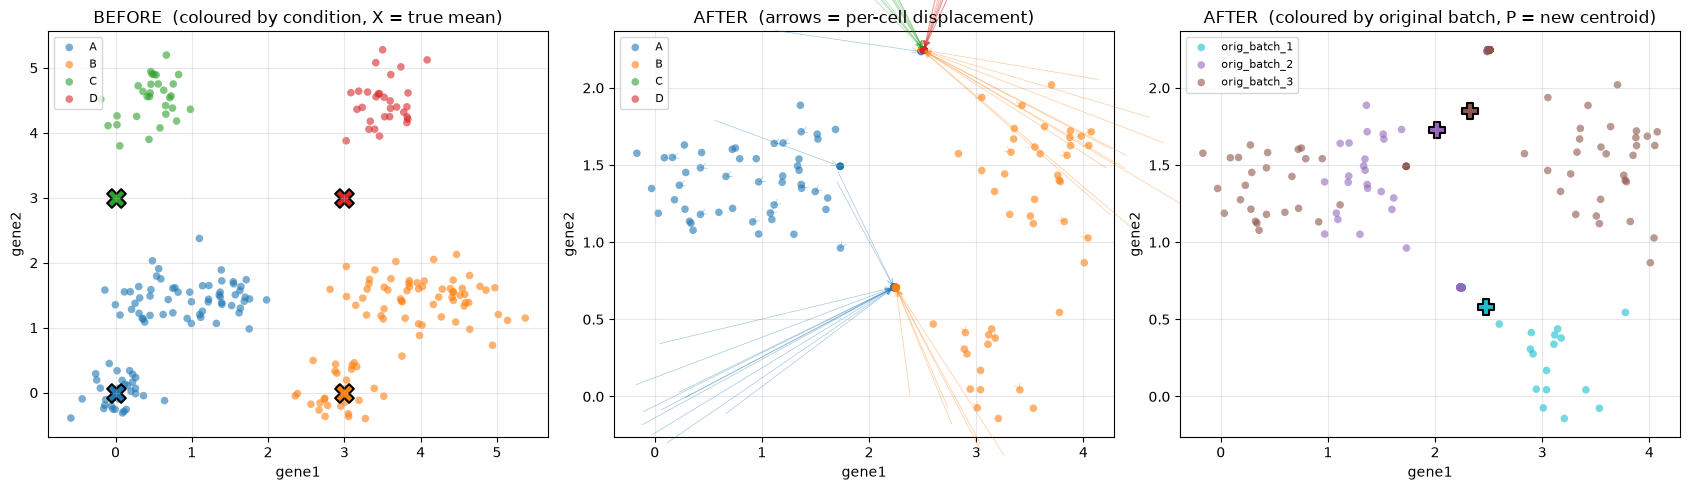

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- panel 1: BEFORE movement, colored by condition ---
for cond in conditions:
    sub = df[df['condition'] == cond]
    axes[0].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
for cond, m in cond_mean.items():
    axes[0].scatter(m[0], m[1], c=cond_colors[cond], marker='X', s=180,
                    edgecolors='black', linewidths=1.5)
axes[0].set_title('BEFORE  (coloured by condition, X = true mean)')
axes[0].set_xlabel('gene1'); axes[0].set_ylabel('gene2')
axes[0].legend(loc='upper left', fontsize=8); axes[0].grid(alpha=0.3)

# --- panel 2: AFTER movement, colored by condition, with displacement arrows ---
for cond in conditions:
    sub = df_moved[df_moved['condition'] == cond]
    axes[1].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
    sub0 = df[df['condition'] == cond]
    # draw arrows from old to new for a subsample to keep it readable
    for x0, y0, x1, y1 in zip(sub0['gene1'].values[::3],
                              sub0['gene2'].values[::3],
                              sub['gene1'].values[::3],
                              sub['gene2'].values[::3]):
        axes[1].annotate('', xy=(x1, y1), xytext=(x0, y0),
                         arrowprops=dict(arrowstyle='->',
                                         color=cond_colors[cond],
                                         lw=0.5, alpha=0.4))
axes[1].set_title('AFTER  (arrows = per-cell displacement)')
axes[1].set_xlabel('gene1'); axes[1].set_ylabel('gene2')
axes[1].legend(loc='upper left', fontsize=8); axes[1].grid(alpha=0.3)

# --- panel 3: AFTER movement, colored by ASSIGNED batch (should differ from original) ---
for b in batches:
    sub = df_moved.assign(assigned_batch=batches_arr)
    sub = df_moved.copy()
    sub['assigned_batch'] = batches_arr
    sub_b = sub[sub['assigned_batch'] == b]
    if len(sub_b) == 0:
        continue
    axes[2].scatter(sub_b['gene1'], sub_b['gene2'], c=batch_colors[b],
                    label=f'orig_batch_{b}', alpha=0.6, s=30,
                    edgecolors='none')
# draw batch centroids in moved positions
mu_final = batch_centroids_of(Y, batches_arr, batches)
for b, m in mu_final.items():
    axes[2].scatter(m[0], m[1], c=batch_colors[b], marker='P', s=140,
                    edgecolors='black', linewidths=1.5)
axes[2].set_title('AFTER  (coloured by original batch, P = new centroid)')
axes[2].set_xlabel('gene1'); axes[2].set_ylabel('gene2')
axes[2].legend(loc='upper left', fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### What the visualization shows

- **Left panel** — the original toy data, with the four true condition means marked by `X`.
- **Middle panel** — after the algorithm. Each arrow is one cell's displacement; the arrows should be short (constraint 1: minimum movement), and they should point across batch boundaries (constraint 2). Different conditions end up on different sides of the plot (constraint 3).
- **Right panel** — same final positions but coloured by the cell's *original* batch. The cell cloud is no longer clustered by batch: each batch's cells are spread across the other batches' Voronoi regions.

### Tuning the trade-off

The two hyper-parameters of the algorithm are:

| parameter     | meaning                                                       | effect of ↑                                                |
|---------------|---------------------------------------------------------------|------------------------------------------------------------|
| `n_iter`      | how many times we recompute centroids and re-assign targets  | tighter fit, possibly more drift                           |
| `w_repel`     | weight of the condition-repulsion term in `Δy_i`              | stronger condition separation, larger per-cell movement    |

If `w_repel = 0` the algorithm only swaps batches and the condition centroids will move only because of the swap. If `w_repel` is too large, the per-cell movement stops being "minimum" — use `history_df` above to monitor the mean displacement and the mean inter-condition centroid distance and pick a value that keeps the displacement small while making `cond_sep` grow.